In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
matplotlib.use('Agg')  # Set backend BEFORE importing pyplot
import matplotlib.pyplot as plt
from pandas import read_csv
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go

%matplotlib inline

In [ ]:
# Optional smaller files for testing
filename = 'alle_151_Netzeinspeiser'
#filename = 'Radius_5000m'
#filename = 'Radius_200m'

dataframe_raw = read_csv('../../Daten/Solar_Load_Profile/Dataframe_Solar_Load_Profile_' + filename + '.csv')

result_path = r'.\results' # path for result diagrams/CSVs

# Count PV-Plants unfiltered
count_per_value_all = len(dataframe_raw['NEI_ID'].value_counts())
print(f"Count PV-Plants from CSV: {count_per_value_all}")

# replace 0 values in column PV_SUMME_INSTALLIERT with values from column MAX_EINSPEISELEISTG
dataframe_raw['PV_SUMME_INSTALLIERT'] = dataframe_raw['PV_SUMME_INSTALLIERT'].where(
    dataframe_raw['PV_SUMME_INSTALLIERT'] > 0, 
    dataframe_raw['MAX_EINSPEISELEISTG']
)   

# drop empty column BESCHEIDLEISTUNG and create new column SPECIFIC_YIELD
dataframe_raw.drop(['BESCHEIDLEISTUNG'], axis=1, inplace=True)
dataframe_raw['SPECIFIC_YIELD'] = (dataframe_raw['SOLAR_LOAD_VALUE'] / dataframe_raw['PV_SUMME_INSTALLIERT']) # spezifischen Ertrag (engl. specific yield) einer Photovoltaikanlage kWh/kWp, Quelle: https://echtsolar.de/wie-viel-strom-erzeugt-eine-pv-anlage/

print(dataframe_raw['SPECIFIC_YIELD'].describe())

# additional column for cloud index
# Hammer, Annette; Kühnert, Jan; Weinreich, Kailash; Lorenz, Elke (2015): Short-Term Forecasting of Surface Solar Irradiance Based on Meteosat-SEVIRI Data Using a Nighttime Cloud Index. In: Remote Sensing 7 (7), S. 9070–9090.
# dataframe_raw['BTD'] = dataframe_raw['IR_039'] - dataframe_raw ['IR_108']

print("Dataframe Raw: dataframe_raw")
print(dataframe_raw.shape)

Count PV-Plants from CSV: 151
Dataframe Raw: dataframe_raw
(2676777, 33)


In [3]:
# create a copy of the raw dataframe to filter and export as CSV for model training
dataframe = dataframe_raw.copy()

# Filter invalid Values in Data
dataframe.loc[dataframe['NEI_ID'] == 3325, 'PV_SUMME_INSTALLIERT'] = dataframe.loc[dataframe['NEI_ID'] == 3325, 'MAX_EINSPEISELEISTG'] # NEI_ID 3325 wrong PV_SUMME_INSTALL → manual Override
dataframe['SPECIFIC_YIELD'] = (dataframe['SOLAR_LOAD_VALUE'] / dataframe['PV_SUMME_INSTALLIERT']) # spezifischen Ertrag in kWh/kWp (engl. specific yield) einer Photovoltaikanlage, Quelle: https://echtsolar.de/wie-viel-strom-erzeugt-eine-pv-anlage/
# dataframe = dataframe[dataframe['NEI_ID'] != 3325] # 4x specific yield vs. installed capacity
dataframe = dataframe[dataframe['TIMESTAMP'] != '2018-07-02 12:15:00'] # Outlier - double LOAD Value
dataframe = dataframe[dataframe['TIMESTAMP'] != '2018-07-13 15:00:00'] # Outlier - double LOAD Value
dataframe = dataframe[dataframe['TIMESTAMP'] != '2018-02-28 14:00:00'] # Outlier - double LOAD Value
dataframe = dataframe[dataframe['SOLAR_LOAD_VALUE'] > 0]
dataframe = dataframe[dataframe['PV_SUMME_INSTALLIERT'] > 0]
# dataframe = dataframe[dataframe['GLOBAL_RADIATION_SENSOR_VALUE'] > 0]
# dataframe = dataframe[dataframe['SOLAR_RADIATION_GLOBALRAD'] > 0]

# Count PV-Plants without invalid Values
count_per_value_all = len(dataframe['NEI_ID'].value_counts())
print(f"Count PV-Plants from CSV: {count_per_value_all}")

# sort Dataframe to learn by TIMESTAMP and NEI_ID
dataframe.sort_values(by=['TIMESTAMP','NEI_ID'], inplace=True)

# dataframe.rename(columns={'GLOBAL_RADIATION_SENSOR_VALUE': 'SENSOR_VALUE', 'GLOBAL_RADIATION_SENSOR_TEMPERATURE': 'SENSOR_TEMPERATURE','PV_SUMME_INSTALLIERT': 'PV_INSTALL', 'SOLAR_RADIATION_GLOBALRAD': 'GLOBALRAD','SOLAR_RADIATION_DIRECTRAD':'DIRECTRAD','SOLAR_RADIATION_DIFFUSERAD':'DIFFUSERAD'}, inplace=True)

print("Dataframe filtered: dataframe")
print(dataframe.shape)
#print(dataframe.head(5))
#print(dataframe.tail(5))

Count PV-Plants from CSV: 140
Dataframe filtered: dataframe
(2269939, 33)


In [4]:
#print('Export '+filename+' timestamped dataframe to CSV')
#dataframe.to_csv('../../../Solar_Load_Profile/Features_Solar_Load_Profile_timestamp_' + filename + '_all_SEVIRI.csv')

#dataframe = dataframe.drop(['NEI_ID','HAUS_ID','ZAEHLPUNKT','TIMESTAMP','RECHTSWERT_GK','HOCHWERT_GK','GLOBAL_RADIATION_SENSOR_NAME','SOLAR_RADIATION_DURATION','SOLAR_LOAD_VALUE','GLOBAL_RADIATION_SENSOR_DISTANCE'], axis=1)

print('Export '+filename+' dataframe to CSV')
dataframe.to_csv('../../Daten/Solar_Load_Profile/2018_Features_Solar_Load_Profile_' + filename + '.csv')

Export alle_151_Netzeinspeiser dataframe to CSV


In [15]:
# Count PV-Plants unfiltered
print(f"Count PV-Plants without Filter: {dataframe_raw['NEI_ID'].nunique()}")
print(f"Rows before filtering:          {len(dataframe_raw)}")

print(f"Rows with SOLAR_LOAD_VALUE > 0: {len(dataframe[dataframe['SOLAR_LOAD_VALUE'] > 0])}")
print(f"Rows with PV_SUMME_INSTALLIERT > 0: {len(dataframe[dataframe['PV_SUMME_INSTALLIERT'] > 0])}")

# replace inf values caused by division-by-zero in SPECIFIC_YIELD
# dataframe.replace([np.inf, -np.inf], np.nan, inplace=True)

# Count PV-Plants filtered    
print(f"Count PV-Plants after Filter: {dataframe['NEI_ID'].nunique()}")
print(f"Rows used for correlation:    {len(dataframe)}")

# calculate correlation for numeric columns only
correlation_matrix = dataframe.select_dtypes(include=[np.number]).corr()

# Define distance intervals
distance_intervals = [(0, 5000), (0, 10000), (0, 15000),(0, 20000), (0, 25000),(0, 5000), (5000, 10000), (10000, 15000),(15000, 20000), (20000, 25000)]
correlation_results = []

for start, end in distance_intervals:
    filtered_dataframe = dataframe[(dataframe['GLOBAL_RADIATION_SENSOR_DISTANCE'] >= start) & (dataframe['GLOBAL_RADIATION_SENSOR_DISTANCE'] < end)]
    # Count PV-Plants
    count_per_value = len(filtered_dataframe['NEI_ID'].value_counts())

    correlation = filtered_dataframe['SPECIFIC_YIELD'].corr(filtered_dataframe['GLOBAL_RADIATION_SENSOR_VALUE'])
    print(f"Correlation over Distance {start} - {end}m {correlation:.2f} PV-Plants count: {count_per_value}")
    correlation_results.append({'Distance_Start': start, 'Distance_End': end, 'Correlation': correlation, 'Count': count_per_value})
    
    # Create a DataFrame from the correlation results
    correlation_dataframe = pd.DataFrame(correlation_results)

    # Write the DataFrame to a CSV file
    correlation_dataframe.to_csv(result_path + '/correlation_results_over_distance.csv', index=False)

Count PV-Plants without Filter: 151
Rows before filtering:          2676777
Rows with SOLAR_LOAD_VALUE > 0: 2269939
Rows with PV_SUMME_INSTALLIERT > 0: 2269939
Count PV-Plants after Filter: 140
Rows used for correlation:    2269939
Correlation over Distance 0 - 5000m 0.93 PV-Plants count: 85
Correlation over Distance 0 - 10000m 0.91 PV-Plants count: 130
Correlation over Distance 0 - 15000m 0.91 PV-Plants count: 138
Correlation over Distance 0 - 20000m 0.91 PV-Plants count: 138
Correlation over Distance 0 - 25000m 0.90 PV-Plants count: 140
Correlation over Distance 0 - 5000m 0.93 PV-Plants count: 85
Correlation over Distance 5000 - 10000m 0.86 PV-Plants count: 45
Correlation over Distance 10000 - 15000m 0.87 PV-Plants count: 8
Correlation over Distance 15000 - 20000m nan PV-Plants count: 0
Correlation over Distance 20000 - 25000m 0.81 PV-Plants count: 2


corr_matrix1.png


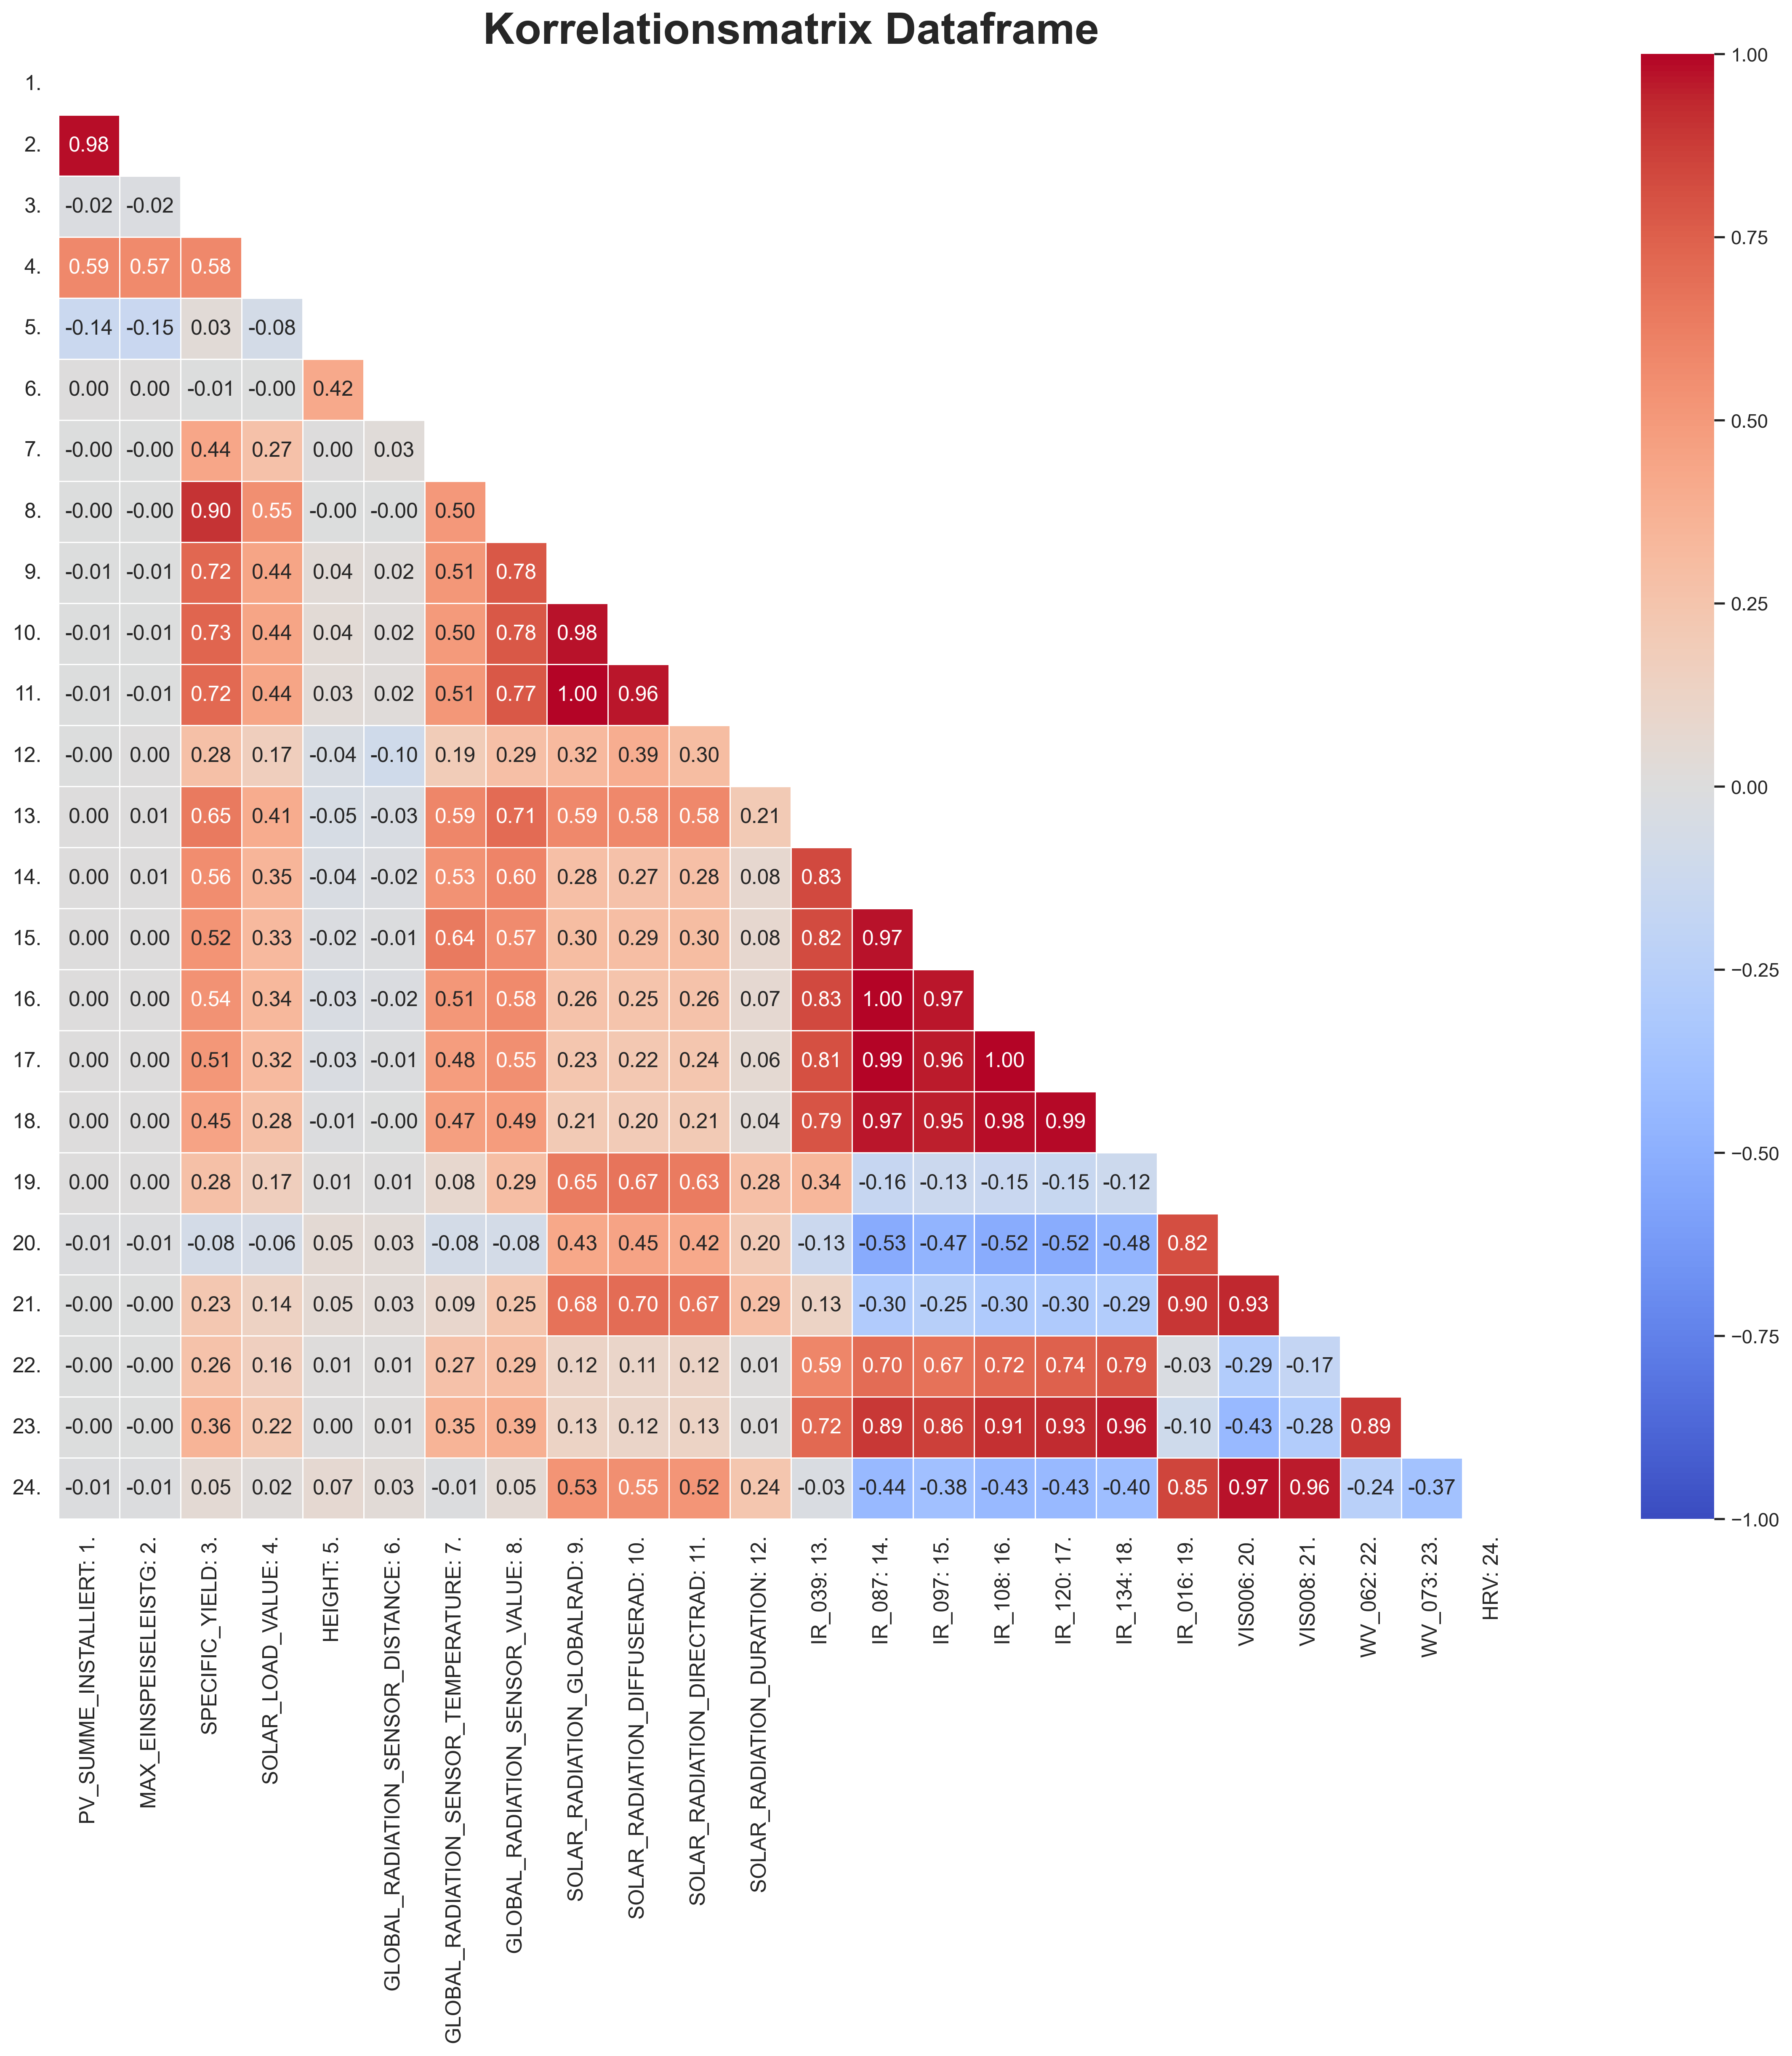

In [6]:
def heatmap():
    features_heatmap = dataframe.drop(['NEI_ID','HAUS_ID','ZAEHLPUNKT','RECHTSWERT_GK','HOCHWERT_GK','GLOBAL_RADIATION_SENSOR_NAME','LON_WGS84', 'LAT_WGS84'], axis=1)
    
    new_column_order = ['PV_SUMME_INSTALLIERT', 'MAX_EINSPEISELEISTG', 'SPECIFIC_YIELD', 'SOLAR_LOAD_VALUE', 'HEIGHT', \
        'GLOBAL_RADIATION_SENSOR_DISTANCE', 'GLOBAL_RADIATION_SENSOR_TEMPERATURE', 'GLOBAL_RADIATION_SENSOR_VALUE', \
        'SOLAR_RADIATION_GLOBALRAD', 'SOLAR_RADIATION_DIFFUSERAD', 'SOLAR_RADIATION_DIRECTRAD', 'SOLAR_RADIATION_DURATION',  \
        'IR_039', 'IR_087', 'IR_097', 'IR_108', 'IR_120', 'IR_134', 'IR_016', 'VIS006', 'VIS008', 'WV_062', 'WV_073', 'HRV']
    features_heatmap = features_heatmap.reindex(columns=new_column_order)

    # display(features_heatmap.head())
    # print(f"\nShape: {features_heatmap.shape}")
    # print(f"Dtypes:\n{features_heatmap.dtypes}")

    #plt.ion()
    plt.figure(figsize=(24,20),dpi = 300)

    #get correlations of each features in dataset (numeric columns only)
    features_numeric = features_heatmap.select_dtypes(include=[np.number])
    corrmat = features_numeric.corr()
    top_corr_features = corrmat.index
    
    # #plot heat map
    # sns.heatmap(features[top_corr_features].corr(),annot=True,cmap='coolwarm',fmt='.2f',annot_kws={"size":10},square=True)
    # Generate a mask for the upper triangle
    mask = np.triu(np.ones_like(corrmat, dtype=bool))

    # scale fontsize generally
    sns.set(font_scale=1.10)

    # Set the background style to white
    sns.set(style="white")
    
    # create heatmap
    ax = sns.heatmap(features_numeric[top_corr_features].corr(), mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidth=.3, vmin=-1, vmax=1, square=True)

    # set title
    plt.title('Korrelationsmatrix Dataframe', fontdict={'weight':'bold', 'size':25})

    # Change y-axis annotations from attribut name to numbers
    ax.set_yticklabels([f'{label}.' for label in range(1, len(features_heatmap.columns)+1)])

    # Get the current labels
    labels = [item.get_text() for item in ax.get_xticklabels()]

    # Add a running number as suffix
    new_labels = [f'{label}: {i}.' for i, label in enumerate(labels, 1)]

    # Set the new labels
    ax.set_xticklabels(new_labels)

    # Set font size for x-axis
    plt.xticks(fontsize=12)

    # Set font size for y-axis
    plt.yticks(fontsize=12)

    # move matrix to the top for full annotations
    plt.subplots_adjust(bottom=0.3)

    print('corr_matrix1.png')

    # save matrix as PNG-file and crop
    plt.savefig(result_path + "/corr_matrix1.png", bbox_inches='tight')
    plt.draw()

heatmap()

boxplot.png


C:\Users\Andreas\AppData\Local\Temp\ipykernel_24296\1598929130.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


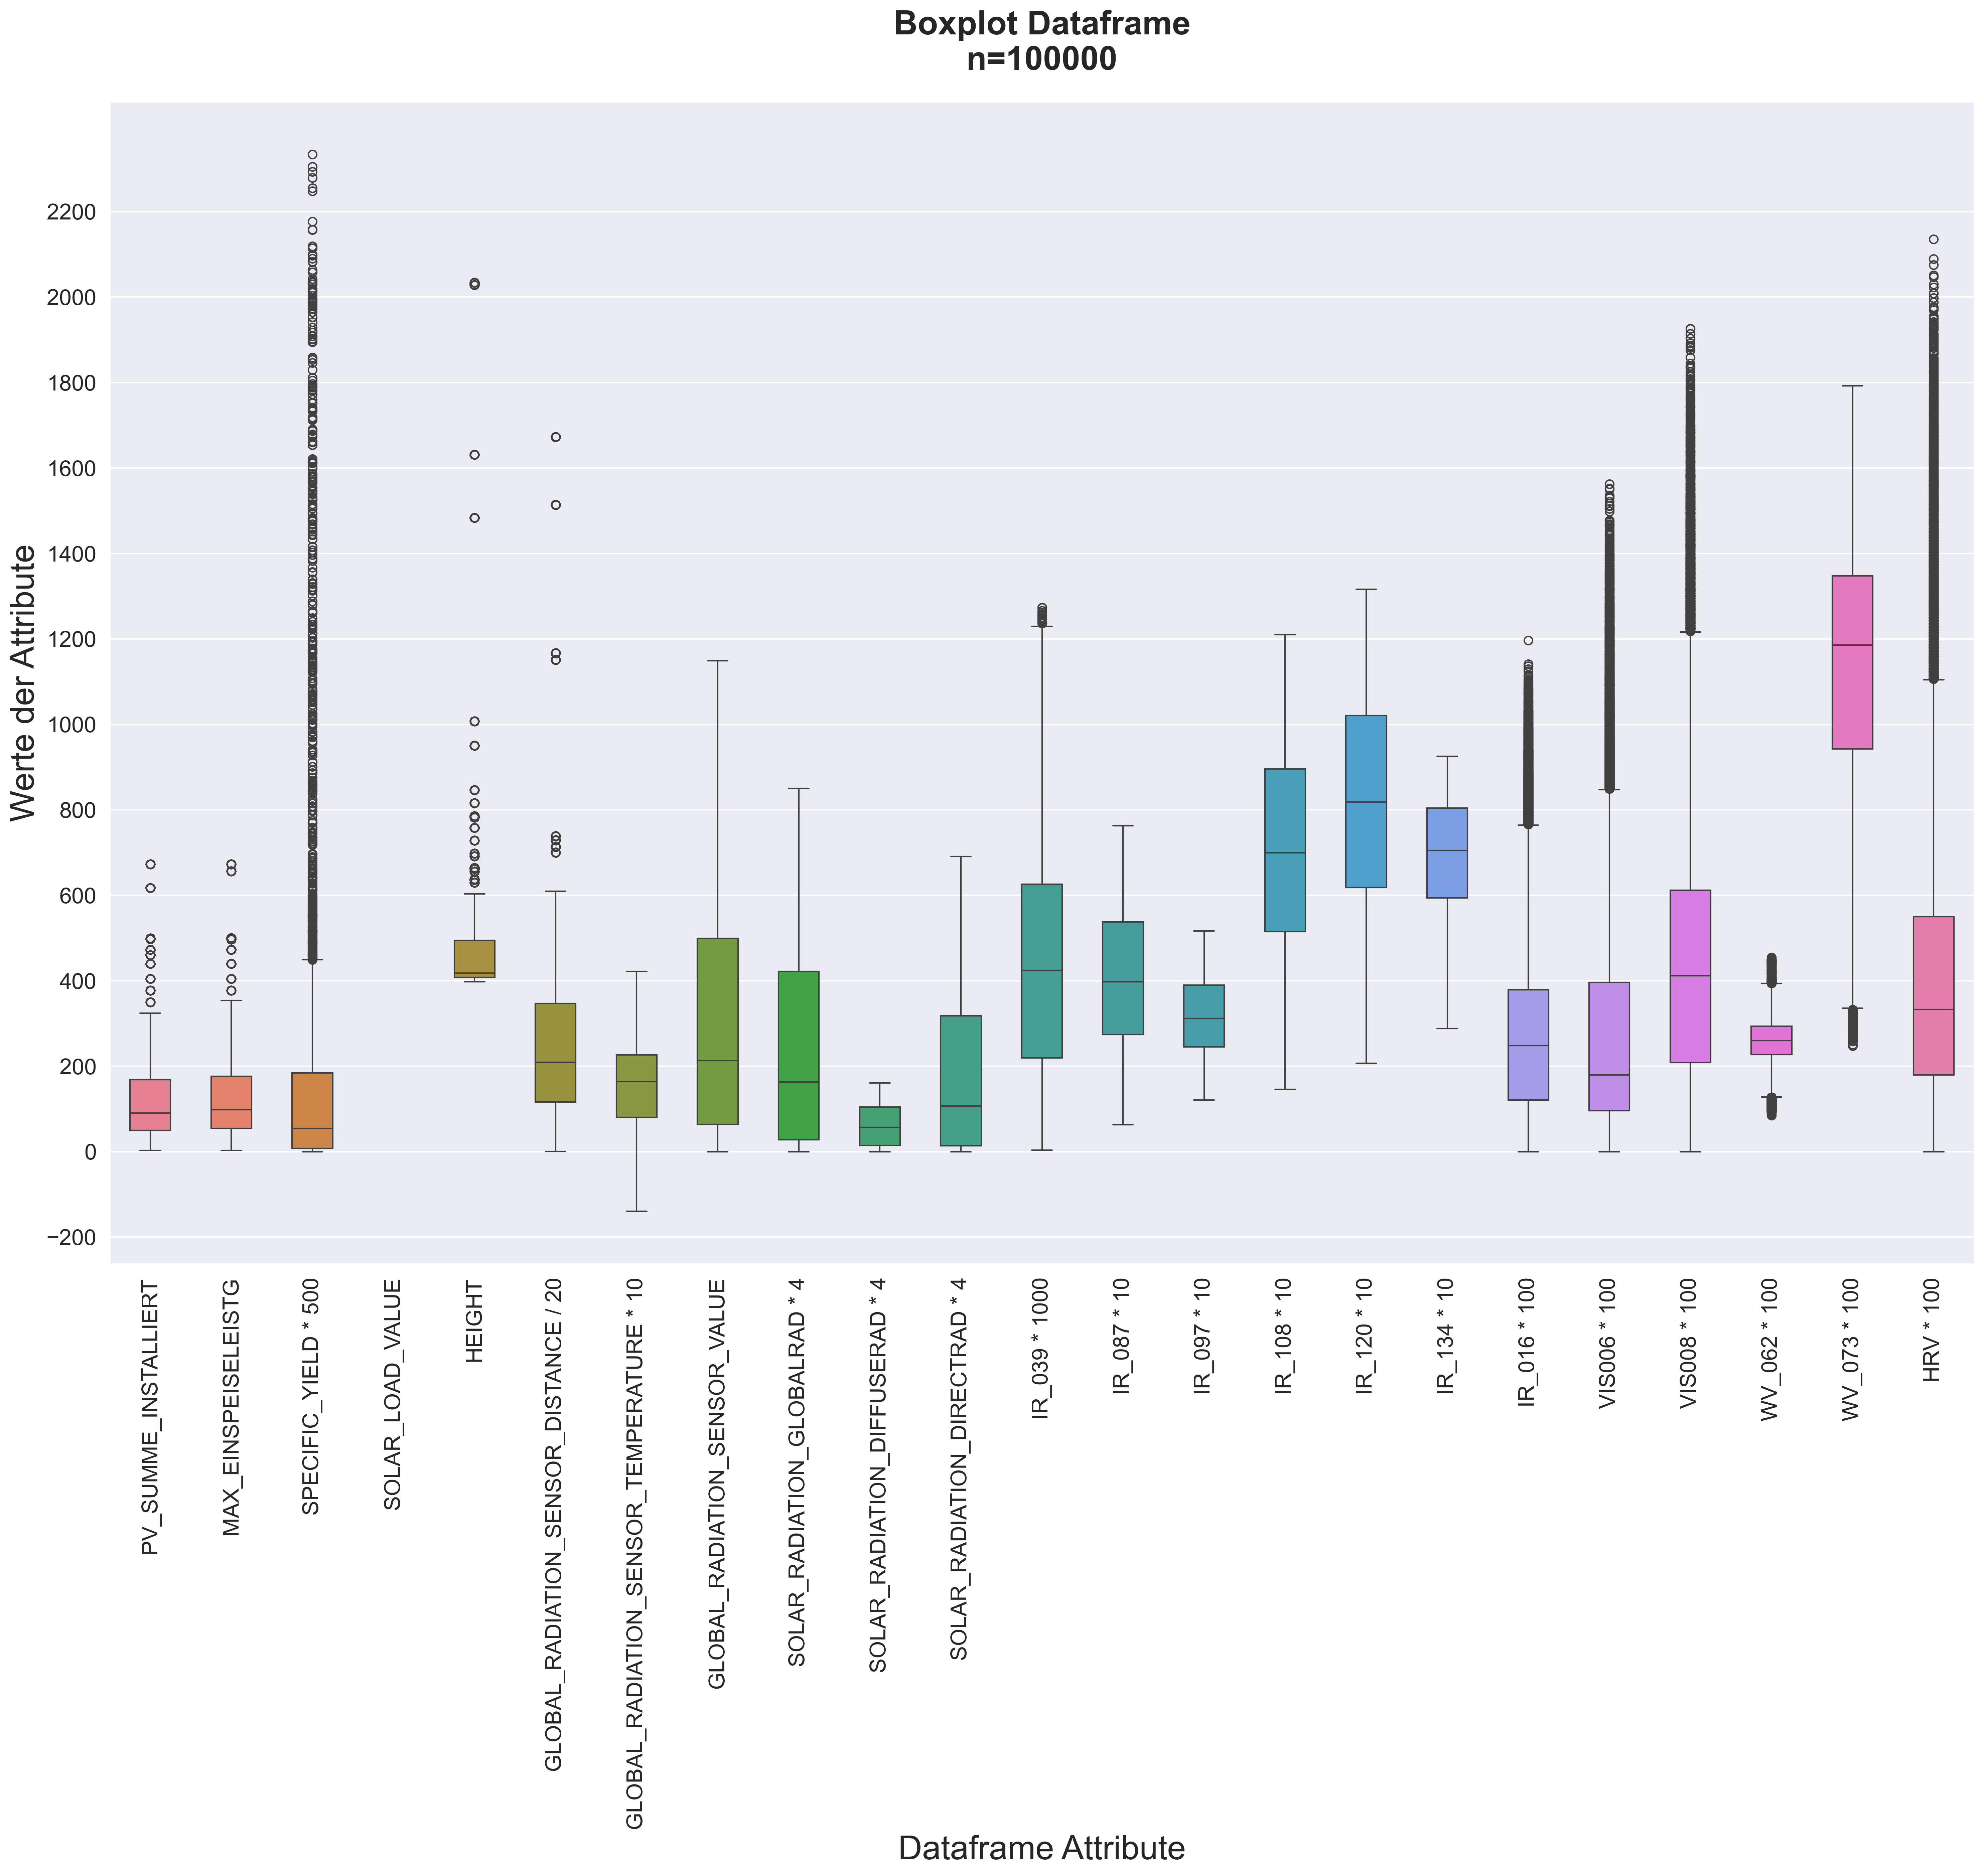

In [7]:
plt.figure(figsize=(24,20),dpi = 300)

# scale fontsize generally
sns.set(font_scale=2)

# change dataframe
features_boxplot = dataframe_raw.drop(['SPECIFIC_YIELD', 'SOLAR_LOAD_VALUE', 'SOLAR_RADIATION_DURATION', 'GLOBAL_RADIATION_SENSOR_DISTANCE','GLOBAL_RADIATION_SENSOR_TEMPERATURE','SOLAR_RADIATION_DIFFUSERAD','SOLAR_RADIATION_DIRECTRAD','SOLAR_RADIATION_GLOBALRAD'], axis=1)

# Sample 100.000 data points from the dataFrame
sample_size = 100000
features_boxplot = features_boxplot.sample(n=sample_size)

features_boxplot['SPECIFIC_YIELD * 500'] = (dataframe_raw['SPECIFIC_YIELD'] * 500) # Scale Factor 500 for boxplot
features_boxplot['SOLAR_LOAD_VALUE * 5'] = (dataframe_raw['SOLAR_LOAD_VALUE'] * 5) # Scale Factor 5 for boxplot 
features_boxplot['SOLAR_RADIATION_DIFFUSERAD * 4'] = (dataframe_raw['SOLAR_RADIATION_DIFFUSERAD'] * 4) # Scale Factor 4 for boxplot
features_boxplot['SOLAR_RADIATION_DIRECTRAD * 4'] = (dataframe_raw['SOLAR_RADIATION_DIRECTRAD'] * 4) # Scale Factor 4 for boxplot
features_boxplot['SOLAR_RADIATION_GLOBALRAD * 4'] = (dataframe_raw['SOLAR_RADIATION_GLOBALRAD'] * 4) # Scale Factor 4 for boxplot
features_boxplot['GLOBAL_RADIATION_SENSOR_DISTANCE / 20'] = (dataframe_raw['GLOBAL_RADIATION_SENSOR_DISTANCE'] / 20) # Scale Factor 20 for boxplot
features_boxplot['GLOBAL_RADIATION_SENSOR_TEMPERATURE * 10'] = (dataframe_raw['GLOBAL_RADIATION_SENSOR_TEMPERATURE'] * 10) # Scale Factor 10 for boxplot
features_boxplot['IR_039 * 1000'] = (dataframe_raw['IR_039'] * 1000) # Scale Factor 1000 for boxplot
features_boxplot['IR_087 * 10'] = (dataframe_raw['IR_087'] * 10) # Scale Factor 10 for boxplot
features_boxplot['IR_097 * 10'] = (dataframe_raw['IR_097'] * 10) # Scale Factor 10 for boxplot
features_boxplot['IR_108 * 10'] = (dataframe_raw['IR_108'] * 10) # Scale Factor 10 for boxplot
features_boxplot['IR_120 * 10'] = (dataframe_raw['IR_120'] * 10) # Scale Factor 10 for boxplot
features_boxplot['IR_134 * 10'] = (dataframe_raw['IR_134'] * 10) # Scale Factor 10 for boxplot
features_boxplot['IR_016 * 100'] = (dataframe_raw['IR_016'] * 100) # Scale Factor 1000 for boxplot
features_boxplot['VIS006 * 100'] = (dataframe_raw['VIS006'] * 100) # Scale Factor 1000 for boxplot
features_boxplot['VIS008 * 100'] = (dataframe_raw['VIS008'] * 100) # Scale Factor 1000 for boxplot
features_boxplot['WV_062 * 100'] = (dataframe_raw['WV_062'] * 100) # Scale Factor 1000 for boxplot
features_boxplot['WV_073 * 100'] = (dataframe_raw['WV_073'] * 100) # Scale Factor 1000 for boxplot
features_boxplot['HRV * 100'] = (dataframe_raw['HRV'] * 100  ) # Scale Factor 100 for boxplot

new_column_order = ['PV_SUMME_INSTALLIERT', 'MAX_EINSPEISELEISTG', 'SPECIFIC_YIELD * 500', 'SOLAR_LOAD_VALUE', 'HEIGHT', \
    'GLOBAL_RADIATION_SENSOR_DISTANCE / 20', 'GLOBAL_RADIATION_SENSOR_TEMPERATURE * 10', 'GLOBAL_RADIATION_SENSOR_VALUE', \
    'SOLAR_RADIATION_GLOBALRAD * 4', 'SOLAR_RADIATION_DIFFUSERAD * 4', 'SOLAR_RADIATION_DIRECTRAD * 4',  
    'IR_039 * 1000', 'IR_087 * 10', 'IR_097 * 10', 'IR_108 * 10', 'IR_120 * 10', 'IR_134 * 10', 'IR_016 * 100', 'VIS006 * 100', 'VIS008 * 100', 'WV_062 * 100', 'WV_073 * 100', 'HRV * 100']
features_boxplot = features_boxplot.reindex(columns=new_column_order)

print('boxplot.png')
plt.clf()
ax = sns.boxplot(data=features_boxplot, width=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

# set title
title='Boxplot Dataframe'
# set title
plt.title(f'{title}\nn={sample_size}', fontweight='bold', y=1.02)

# label axis
ax.set_xlabel('Dataframe Attribute',)
ax.set_ylabel('Werte der Attribute')

    # Set font size for x-axis
plt.xticks(fontsize=16)

# Set font size for y-axis
plt.yticks(fontsize=16)

# set intervall to 200
ax.set_yticks(range(-200, 2400, 200))

# move boxplot to the top for full annotations
plt.subplots_adjust(bottom=0.3)

# save boxplot as PNG-file and crop
plt.savefig(result_path + "/boxplot.png", bbox_inches='tight', dpi=300)
plt.draw()

dataframe_scatterplot
Der Korrelationskoeffizient zwischen 'SPECIFIC_YIELD' und 'GLOBAL_RADIATION_SENSOR_VALUE' beträgt: 0.7364
Number of zeros in SOLAR_LOAD_VALUE: 7546
Number of zeros in PV_SUMME_INSTALLIERT: 0
Stichprobe:
Spaltenbezeichnungen:
Index(['NEI_ID', 'HAUS_ID', 'ZAEHLPUNKT', 'TIMESTAMP', 'RECHTSWERT_GK',
       'HOCHWERT_GK', 'LON_WGS84', 'LAT_WGS84', 'HEIGHT',
       'PV_SUMME_INSTALLIERT', 'SOLAR_LOAD_VALUE',
       'GLOBAL_RADIATION_SENSOR_NAME', 'GLOBAL_RADIATION_SENSOR_DISTANCE',
       'GLOBAL_RADIATION_SENSOR_VALUE', 'GLOBAL_RADIATION_SENSOR_TEMPERATURE',
       'SOLAR_RADIATION_DIFFUSERAD', 'SOLAR_RADIATION_DIRECTRAD',
       'SOLAR_RADIATION_DURATION', 'SOLAR_RADIATION_GLOBALRAD',
       'MAX_EINSPEISELEISTG', 'VIS006', 'VIS008', 'IR_016', 'IR_039', 'WV_062',
       'WV_073', 'IR_087', 'IR_097', 'IR_108', 'IR_120', 'IR_134', 'HRV',
       'SPECIFIC_YIELD', 'CORR_SY_SENSOR'],
      dtype='str')
(50000, 34)


<Figure size 640x480 with 0 Axes>

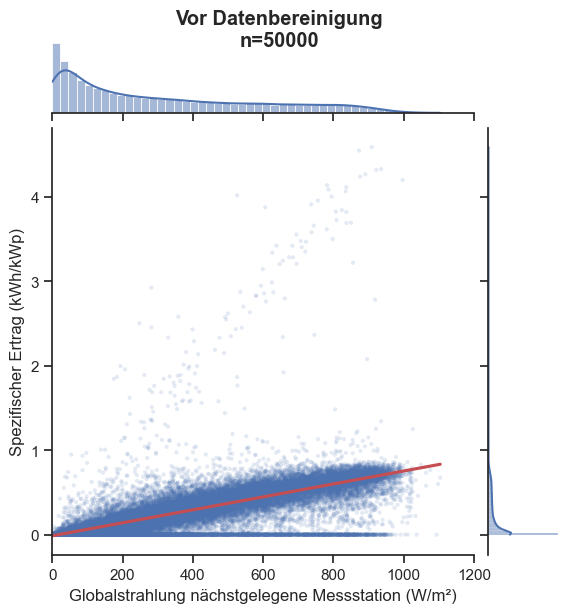

dataframe_clean
Der Korrelationskoeffizient zwischen 'SPECIFIC_YIELD' und 'GLOBAL_RADIATION_SENSOR_VALUE' beträgt: 0.9041
Number of zeros in SOLAR_LOAD_VALUE: 0
Number of zeros in PV_SUMME_INSTALLIERT: 0
Stichprobe:
Spaltenbezeichnungen:
Index(['NEI_ID', 'HAUS_ID', 'ZAEHLPUNKT', 'TIMESTAMP', 'RECHTSWERT_GK',
       'HOCHWERT_GK', 'LON_WGS84', 'LAT_WGS84', 'HEIGHT',
       'PV_SUMME_INSTALLIERT', 'SOLAR_LOAD_VALUE',
       'GLOBAL_RADIATION_SENSOR_NAME', 'GLOBAL_RADIATION_SENSOR_DISTANCE',
       'GLOBAL_RADIATION_SENSOR_VALUE', 'GLOBAL_RADIATION_SENSOR_TEMPERATURE',
       'SOLAR_RADIATION_DIFFUSERAD', 'SOLAR_RADIATION_DIRECTRAD',
       'SOLAR_RADIATION_DURATION', 'SOLAR_RADIATION_GLOBALRAD',
       'MAX_EINSPEISELEISTG', 'VIS006', 'VIS008', 'IR_016', 'IR_039', 'WV_062',
       'WV_073', 'IR_087', 'IR_097', 'IR_108', 'IR_120', 'IR_134', 'HRV',
       'SPECIFIC_YIELD', 'CORR_SY_SENSOR'],
      dtype='str')
(50000, 34)


<Figure size 640x480 with 0 Axes>

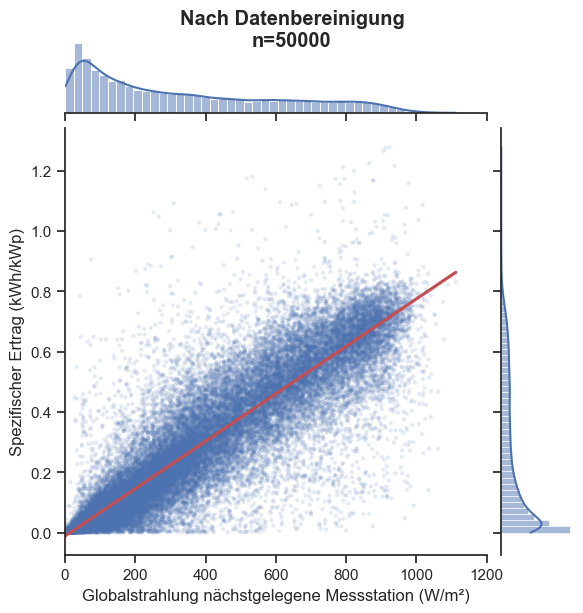

In [8]:
def scatterplot():
    # Replace inf and -inf with NaN
    dataframe_scatterplot = dataframe_raw.replace([np.inf, -np.inf], np.nan)
    
    # filter outliers with zero values in SOLAR_LOAD_VALUE and GLOBAL_RADIATION_SENSOR_VALUE
    dataframe_clean = dataframe.replace([np.inf, -np.inf], np.nan)
    dataframe_clean = dataframe_clean[dataframe_clean['SOLAR_LOAD_VALUE'] > 0]
    dataframe_clean = dataframe_clean[dataframe_clean['GLOBAL_RADIATION_SENSOR_VALUE'] > 0]

    # loop through both dataframes
    for df_name, df, title in [("dataframe_scatterplot", dataframe_scatterplot, 'Vor Datenbereinigung'), ("dataframe_clean", dataframe_clean, 'Nach Datenbereinigung')]:
        print(df_name)
        correlation_coefficient = df['SPECIFIC_YIELD'].corr(df['GLOBAL_RADIATION_SENSOR_VALUE'])
        print(f"Der Korrelationskoeffizient zwischen 'SPECIFIC_YIELD' und 'GLOBAL_RADIATION_SENSOR_VALUE' beträgt: {correlation_coefficient:.4f}")
        
        # Set the random seed for reproducibility
        np.random.seed(42)

        # Sample 50.000 data points from the original DataFrame
        sample_size = 50000
        df = df.sample(n=sample_size)
        
        # calculate correlation factor
        df['CORR_SY_SENSOR'] = (df['SPECIFIC_YIELD'] / df['GLOBAL_RADIATION_SENSOR_VALUE']) # Verhältnis zwischen SPECIFIC_YIELD und SENSOR_VALUE zur Outlier Detection

        # Count the number of zeros in the 'SOLAR_LOAD_VALUE' and 'PV_SUMME_INSTALLIERT' columns
        zero_count_solar = (df['SOLAR_LOAD_VALUE'] == 0).sum()
        zero_count_pv = (df['PV_SUMME_INSTALLIERT'] == 0).sum()
        print(f"Number of zeros in SOLAR_LOAD_VALUE: {zero_count_solar}")
        print(f"Number of zeros in PV_SUMME_INSTALLIERT: {zero_count_pv}")
        
        print("Stichprobe:")
        # print(dataframe_sample.describe(include='all'))
        print("Spaltenbezeichnungen:")
        print(df.columns)
        print(df.shape)

        # Clear the current figure
        plt.clf()

        # Set the theme of the plots
        sns.set_theme(style="ticks")

        # Create a jointplot with regression
        g = sns.jointplot(x=df['GLOBAL_RADIATION_SENSOR_VALUE'], y=df['SPECIFIC_YIELD'], kind="reg", xlim = (0, 1200), robust=True, ci=None, marker='.', scatter_kws={'alpha': 0.15, 'edgecolors': 'none'}, line_kws=dict(color='r'))

        # set title
        g.fig.suptitle(f'{title}\nn={sample_size}', fontweight='bold', y=1.02)

        # label axis
        g.set_axis_labels("Globalstrahlung nächstgelegene Messstation (W/m²)", "Spezifischer Ertrag (kWh/kWp)")

        # Save the plot as a PNG file with high resolution
        plt.savefig(result_path + f"/jointplot_{df_name}_reg_kind.png", bbox_inches='tight', dpi=300)
        plt.show()

scatterplot()

<Figure size 640x480 with 0 Axes>

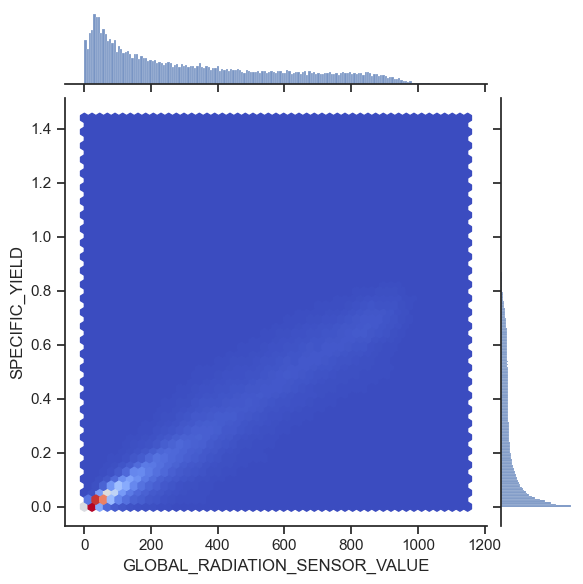

In [9]:

# Replace inf and -inf with NaN
sample_df = dataframe.replace([np.inf, -np.inf], np.nan)

# # Save the static version of the plot
# plt.clf()
# plt.hexbin(sample_df['GLOBAL_RADIATION_SENSOR_VALUE'], sample_df['SPECIFIC_YIELD'], gridsize=50, cmap='Greens')
# plt.scatter(outliers['GLOBAL_RADIATION_SENSOR_VALUE'], outliers['SPECIFIC_YIELD'], color='red')
# plt.savefig("hexbin.png")

plt.clf()
sns.set_theme(style="ticks")
sns.jointplot(x=sample_df['GLOBAL_RADIATION_SENSOR_VALUE'], y=sample_df['SPECIFIC_YIELD'], kind="hex", cmap='coolwarm')
plt.savefig(result_path + "/jointplot.png")

Distribution_SPECIFIC_YIELD.png


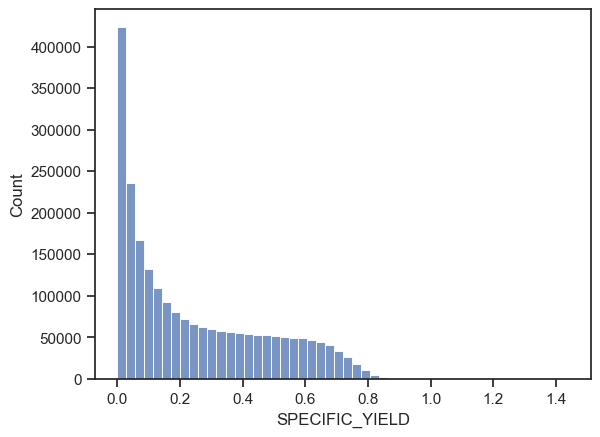

In [10]:
#plot the distribution of the DataFrame 'SPECIFIC_YIELD' column
plt.clf()
sns.histplot(dataframe['SPECIFIC_YIELD'],kde=False,bins=50)
print('Distribution_SPECIFIC_YIELD.png')
plt.savefig(result_path + "/Distribution_SPECIFIC_YIELD.png", bbox_inches='tight')
plt.draw()

Distribution_GLOBAL_RADIATION_SENSOR_VALUE.png


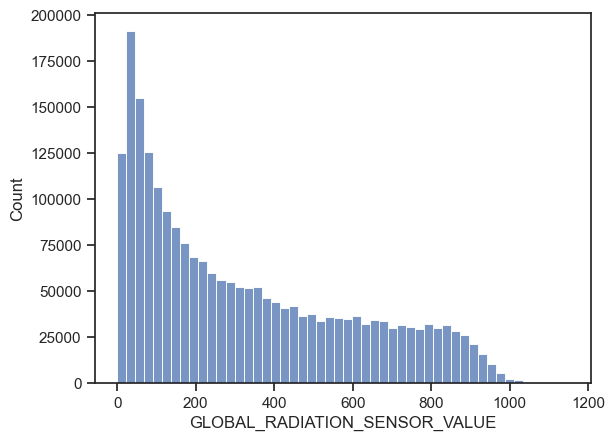

In [11]:

#plot the distribution of the DataFrame 'GLOBAL_RADIATION_SENSOR_VALUE' column
plt.clf()
sns.histplot(dataframe['GLOBAL_RADIATION_SENSOR_VALUE'],kde=False,bins=50)
print('Distribution_GLOBAL_RADIATION_SENSOR_VALUE.png')
plt.savefig(result_path + "/Distribution_GLOBAL_RADIATION_SENSOR_VALUE.png", bbox_inches='tight')
plt.draw()

Distribution_DISTANCE.png


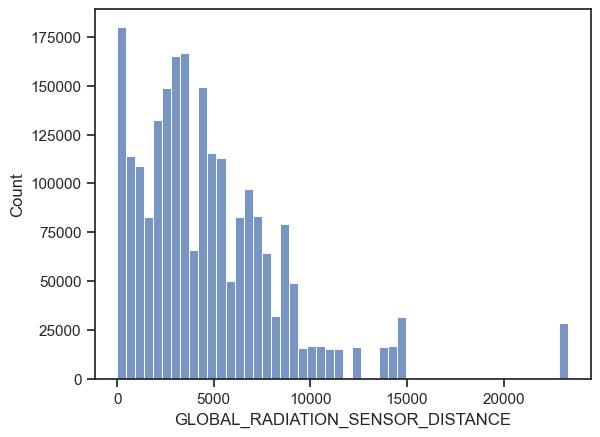

In [12]:
#plot the distribution of the DataFrame 'DISTANCE' column
plt.clf()
sns.histplot(dataframe['GLOBAL_RADIATION_SENSOR_DISTANCE'],kde=False,bins=50)
print('Distribution_DISTANCE.png')
plt.savefig(result_path + "/Distribution_DISTANCE.png", bbox_inches='tight')
plt.draw()

JOIN_SPECIFIC_YIELD__GLOBAL_RADIATION_SENSOR_VALUE_hex.png


<Figure size 640x480 with 0 Axes>

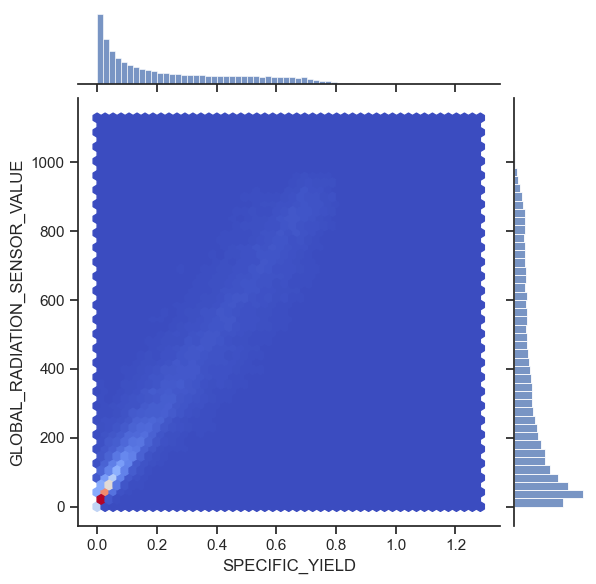

In [13]:
plt.clf()

# Sample 50,000 data points from the original DataFrame
sample_size = 50000
df = dataframe.sample(n=sample_size)

sns.jointplot(x='SPECIFIC_YIELD',y='GLOBAL_RADIATION_SENSOR_VALUE',data=df,kind='hex',cmap='coolwarm')
print('JOIN_SPECIFIC_YIELD__GLOBAL_RADIATION_SENSOR_VALUE_hex.png')
plt.savefig(result_path + "/JOIN_SPECIFIC_YIELD__GLOBAL_RADIATION_SENSOR_VALUE_hex.png", bbox_inches='tight')
plt.draw()

JOIN_SPECIFIC_YIELD__GLOBAL_RADIATION_SENSOR_VALUE_reg.png


<Figure size 640x480 with 0 Axes>

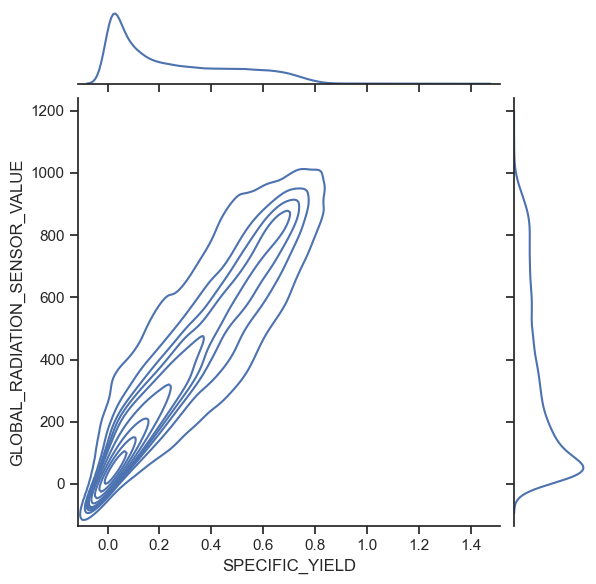

In [14]:
plt.clf()

# Sample 50,000 data points from the original DataFrame
sample_size = 50000
df = dataframe.sample(n=sample_size)

sns.jointplot(x='SPECIFIC_YIELD',y='GLOBAL_RADIATION_SENSOR_VALUE',data=df,kind="kde")
print('JOIN_SPECIFIC_YIELD__GLOBAL_RADIATION_SENSOR_VALUE_reg.png')
plt.savefig(result_path + "/JOIN_SPECIFIC_YIELD__GLOBAL_RADIATION_SENSOR_VALUE_reg.png", bbox_inches='tight')
plt.draw()